# Solving the 1D Advection-Diffusion-Reaction (ADR) Equation

In this notebook, we will walk through the process of solving a 1D Advection-Diffusion-Reaction (ADR) equation using finite difference methods. The ADR equation is a combination of three types of partial differential equations: advection, diffusion, and reaction. The general form of the ADR equation is:

$ u_t = (k(x) u_x)_x - v(x) u_x + g(u) + f(x, t) $

where:
- $ u_t $ is the time derivative of $ u $.
- $ (k(x) u_x)_x $ represents the diffusion term.
- $ -v(x) u_x $ represents the advection term.
- $ g(u) $ represents the reaction term.
- $ f(x, t) $ is an external forcing function.

We will implement a numerical solver for this equation and then use it to solve a specific example.

First, we need to import the necessary libraries. We will use `numpy` for numerical operations and `matplotlib` for plotting the results.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

Next, we define the function `solve_ADR` that will solve the ADR equation. This function takes several parameters:
- `xmin`, `xmax`: The spatial domain limits.
- `tmin`, `tmax`: The time domain limits.
- `k`, `v`, `g`, `dg`, `f`, `u0`: Functions representing the coefficients and initial conditions.
- `Nx`, `Nt`: The number of spatial and temporal grid points.

In [2]:
def solve_ADR(xmin, xmax, tmin, tmax, k, v, g, dg, f, u0, Nx, Nt):
    """Solve 1D
    u_t = (k(x) u_x)_x - v(x) u_x + g(u) + f(x, t)
    with zero boundary condition.
    """
    x = np.linspace(xmin, xmax, Nx)
    t = np.linspace(tmin, tmax, Nt)
    h = x[1] - x[0]
    dt = t[1] - t[0]
    h2 = h ** 2

    D1 = np.eye(Nx, k=1) - np.eye(Nx, k=-1)
    D2 = -2 * np.eye(Nx) + np.eye(Nx, k=-1) + np.eye(Nx, k=1)
    D3 = np.eye(Nx - 2)
    k = k(x)
    M = -np.diag(D1 @ k) @ D1 - 4 * np.diag(k) @ D2
    m_bond = 8 * h2 / dt * D3 + M[1:-1, 1:-1]
    v = v(x)
    v_bond = 2 * h * np.diag(v[1:-1]) @ D1[1:-1, 1:-1] + 2 * h * np.diag(
        v[2:] - v[: Nx - 2]
    )
    mv_bond = m_bond + v_bond
    c = 8 * h2 / dt * D3 - M[1:-1, 1:-1] - v_bond
    f = f(x[:, None], t)

    u = np.zeros((Nx, Nt))
    u[:, 0] = u0(x)
    for i in range(Nt - 1):
        gi = g(u[1:-1, i])
        dgi = dg(u[1:-1, i])
        h2dgi = np.diag(4 * h2 * dgi)
        A = mv_bond - h2dgi
        b1 = 8 * h2 * (0.5 * f[1:-1, i] + 0.5 * f[1:-1, i + 1] + gi)
        b2 = (c - h2dgi) @ u[1:-1, i].T
        u[1:-1, i + 1] = np.linalg.solve(A, b1 + b2)
    return x, t, u

Now, we define the `main` function that sets up the specific problem we want to solve and calls the `solve_ADR` function. We also define the true solution for comparison.

In [3]:
def main():
    xmin, xmax = -1, 1
    tmin, tmax = 0, 1
    k = lambda x: x ** 2 - x ** 2 + 1
    v = lambda x: np.ones_like(x)
    g = lambda u: u ** 3
    dg = lambda u: 3 * u ** 2
    f = (
        lambda x, t: np.exp(-t) * (1 + x ** 2 - 2 * x)
                     - (np.exp(-t) * (1 - x ** 2)) ** 3
    )
    u0 = lambda x: (x + 1) * (1 - x)
    u_true = lambda x, t: np.exp(-t) * (1 - x ** 2)

    Nx, Nt = 100, 100
    x, t, u = solve_ADR(xmin, xmax, tmin, tmax, k, v, g, dg, f, u0, Nx, Nt)

    print(np.max(abs(u - u_true(x[:, None], t))))
    plt.plot(x, u)
    plt.show()

Finally, we run the `main` function to solve the ADR equation and plot the results.

2.5168185132873333e-05


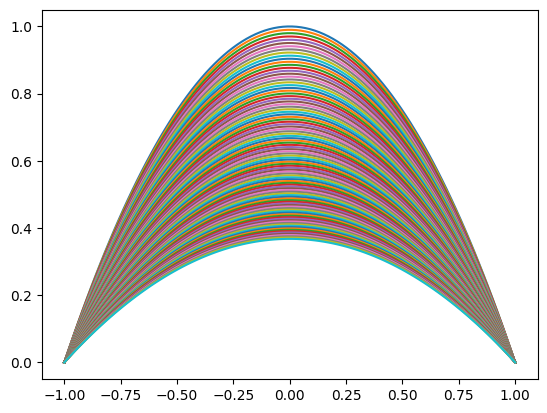

In [4]:
main()